# Bayesian Statistics 
In *Python for Finance*, chapter 13 introduces *Bayesian Statistics* - a method of applying probability to statistical problems. The PyMC3 package is introduced in the book with a simple example of drawing balls out of two different boxes. Each box has a different percentage of black balls vs red balls. What is the likelihood of drawing a specific color ball from a given box? That is what we are trying to find with a Bayesian approach.

Here I'll work through a Towards Data Science [article written by Susan Li](https://towardsdatascience.com/hands-on-bayesian-statistics-with-python-pymc3-arviz-499db9a59501), which grounds us with an easy to follow explanation of Gaussian Inference, Posterior Predictive Checks, Group Comparison, and Hierarchical Linear Regression. I found this article helped me better understand the example in the book.

### Introduction to Bayesian Statistics
[Bayesian statistics](https://en.wikipedia.org/wiki/Bayesian_statistics) is named after Thomas Bayes, who published a paper in 1763 titled *An Essay towards solving a Problem in the Doctrine of Chances*. This paper formed the basis for several more works that spanned across the 18th and 19th centuries, but the term *Bayesian* was not commonly used until the 1950s. In the 21st century, Bayesian models are often used as a framework to express and understand next-generation deep neural networks. With more powerful computation and algorithms such as *Markov chain Monte Carlo*, Bayesian methods are seeing increased use.

Bayesian models can also be called *probabilistic models*, given they are built using probabilities to quantify uncertainty. Therefore, the answers provided by bayesian models are distributions, not point estimates.

Consider the Bayesian Approach:

* Create a hypothesis from a data set, then include a *Prior* and *Likelihood* function.

* Create a bayesian model using the data set and probability, in accordance with our hypothesis. Ensure that the model and the original data set agree with one another.

* Use the model to update our view of the data set.

### PyMC3 & Arviz
PyMC3 is a Python package that enables probabilistic programming with intuitive syntax. ArviZ is a supplemental Python library for PyMC3 that helps with the interpretation and visualization of posterior distributions.

In this notebook, I'll follow Susan's approach to a Bayesian analysis:

- framing the question
- building models
- eliciting prior probabilities
- implementing the final posterior distribution

### The Data
The example data set used in the article shows us pricing data for Spanish High Speed Rail tickets.

In [1]:
from scipy import stats
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import pymc3 as pm
import seaborn as sns
import pandas as pd
from theano import shared
from sklearn import preprocessing

In [2]:
print('Running on PyMC3 v{}'.format(pm.__version__))

Running on PyMC3 v3.11.2


In [3]:
data = pd.read_csv('shsr_pricing.csv')
data.head()

,insert_date,origin,destination,start_date,end_date,train_type,price,train_class,fare
0,2019-04-22 08:00:25,MADRID,SEVILLA,2019-04-28 08:30:00,2019-04-28 11:14:00,ALVIA,NaN,Turista,Flexible
1,2019-04-22 10:03:24,MADRID,VALENCIA,2019-05-20 06:45:00,2019-05-20 08:38:00,AVE,21.95,Turista,Promo
2,2019-04-25 19:19:46,MADRID,SEVILLA,2019-05-29 06:20:00,2019-05-29 09:16:00,AV City,38.55,Turista,Promo
3,2019-04-24 06:21:57,SEVILLA,MADRID,2019-05-03 08:35:00,2019-05-03 15:26:00,LD-MD,34.35,Turista con enlace,Promo +
4,2019-04-19 21:13:55,VALENCIA,MADRID,2019-05-10 09:40:00,2019-05-10 11:20:00,AVE,45.30,Turista,Promo


In [4]:
data.isnull().sum()/len(data)

insert_date    0.000000
origin         0.000000
destination    0.000000
start_date     0.000000
end_date       0.000000
train_type     0.000000
price          0.119467
train_class    0.003993
fare           0.003993
dtype: float64

Both the train_class and fare columns are categorical columns, so we will fill those missing values with the most common category respectively.

~12% of the values in the price column are missing. For the missing values, we can use the mean of the respective fare types to fill them (i.e. a row contianing a missing value for price will have the price column filled in with the mean value calculated from all prices that have the same fare category). This is done after filling in the categorical data so that we are working with a complete data set.

In [5]:
data['train_class'] = data['train_class'].fillna(data['train_class'].mode().iloc[0])
data['fare'] = data['fare'].fillna(data['fare'].mode().iloc[0])
grouped = data.groupby('fare')
data['price'] = grouped[['price']].transform(lambda x: x.fillna(x.mean()))

check to make sure all the missing values are filled.

In [6]:
data.isnull().sum()/len(data)

insert_date    0.0
origin         0.0
destination    0.0
start_date     0.0
end_date       0.0
train_type     0.0
price          0.0
train_class    0.0
fare           0.0
dtype: float64

### Gaussian Inferences

The [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) plot of the rail ticket price shows a Gaussian-like distribution, with some exceptions tailing far away from the mean.

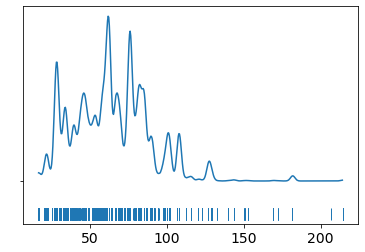

In [7]:
az.plot_kde(data['price'].values, rug=True)
plt.yticks([0], alpha=0);

### Model
The model for this notebook is to perform Gaussian inferences on the rail ticket pricing data. We can make the assumption that a Gaussian distribution is a proper description for rail ticket price. Since we do not know the mean or standard deviation, we'll set priors for both of them. ∴ a reasonable model could be as follows:

**Instantiate a Model with PyMC3:**

Setting priors:

* μ will be the mean of a population, where we do not know the possible values of μ, but can see its a Gaussian distribution. Since we don't know the mean priors will be used, I'll borrow Susan's 0 and 300 values given I've never rode the *High Speed Spanish Rail* before.

* σ is the standard deviation of the population, which can only be positive. PyMC3 models use a HalfNormal distribution to represent this.

Calculate likelihood of ticket prices:

* y - an observed variable that represents data from a normal distribution, given parameters μ and σ.

* We'll draw 1000 posterior samples via the built in NUTS sampler.

In [ ]:
# PyMC3 models are wrapped in a with-statement.
with pm.Model() as model_g:
    μ = pm.Uniform('μ', lower=0, upper=300)
    σ = pm.HalfNormal('σ', sd=10)
    y = pm.Normal('y', mu=μ, sd=σ, observed=data['price'].values)
    trace_g = pm.sample(1000, tune=1000, return_inferencedata=True)

We wan to tell PyMC3 to condition for the unknown from our known (observed) data. This is going to be the pricing of the rail ticket. We plot the gaussian model trace, using a built-in function that leverages a [theano graph](https://theano-pymc.readthedocs.io/en/latest/extending/graphstructures.html).

In [ ]:
az.plot_trace(trace_g, compact=False, legend=True, figsize=(20,8));

* On the left are KDE plots that tell us the probability of **y** (ticket price) given each specified parameter from the PyMC3 model along the x-axis.

* On the right are individual sampled values at each step from the NUTS sampler. The trace plot visually shows plausible values from the posterior.

* In this example, the posterior is bi-dimensional - the above shows the marginal distributions of each given parameter.

A couple of observations:

* The two sampling chains for the individual parameters on the left show no anamolies and minimal drift, indicating the chains are well converged and stationary.

* The peak (maximum posterior estimate) of each parameter is close to the true parameters.

Below is a plot of the joint distributions:

In [ ]:
az.plot_pair(trace_g, kind='kde', marginals=True, fill_last=False);

The pair plot doesn't show correlation between the two parameters, meaning there probably is not [collinearity](https://www.britannica.com/topic/collinearity-statistics) in this model. The underlying library, [arviz](https://arviz-devs.github.io/arviz/), allows us to look at a detailed summary of the posterier distribution:

In [ ]:
az.summary(trace_g)

To interpret and report the results of a Bayesian inference, arviz also lets us plot the summary with the mean and *Highest Posterior Density* (HPD).

In [ ]:
az.plot_posterior(trace_g, figsize=(25,6));

Bayesian inference shows us the entire distribution of values in the data set. Arviz uses a default value of 94% when computing HPD - not that HPD intervals are not the same as confidence intervals. These graphs are telling us there is a 94% probability that the mean ticket price is between 63.8 euro and 64.4 euro. 

* Consider our priors, this probability is based on our known ticket prices - which could have probably changed since the data set was formatted.

To verify the convergence, Susan used a *Gelman Rubin* test, which has since been [deprecated](https://github.com/arviz-devs/arviz/issues/361) in favor of arviz' rhat function, along with other [diagnostic](https://arviz-devs.github.io/arviz/api/diagnostics.html) functions.

In [ ]:
pm.rhat(trace_g)

The rhat function returns an xarray dataset. We're interested in looking at the data variables and verifying that they are close to 1, [which is what we want](https://www.displayr.com/convergence-hb-maxdiff/#:~:text=Rhat%20refers%20to%20the%20potential,to%20the%20within%2Dchain%20variance.).

We'll also look at the *Bayesian fraction of missing information*, (BFMI). This shows us how well the model is specified, arviz relays that values smaller than 0.3 indicate poor sampling. Our values look good in this example, but if you want, take see a more detailed explanation of this [interpretation](https://arxiv.org/pdf/1604.00695v1.pdf).

In [ ]:
pm.bfmi(trace_g)

In [ ]:
az.plot_energy(trace_g)

### Posterior Predictive Checks

To validate the model, we'll use *Posterior predictive checks* (PPCs). These checks generate data from the model using draws from the posterior.

We've already computed the posterior (trac_g) above, now we draw 1000 samples from the trace and for each sample we draw 25798 random numbers from a normal distribution that is specified by our parameters μ and σ in that sample. 

In [ ]:
ppc = pm.sample_posterior_predictive(trace_g, samples=2000, model=model_g)
np.asarray(ppc['y']).shape

the ppc variable contains 1000 generated data sets, each with 25798 samples. Every data set in ppc uses a different parameter setting from the original draw of the posterior (trace_g). Using a histogram, we can see that the inferred mean is very close to the actual mean rail ticket price.

In [ ]:
_, ax = plt.subplots(figsize=(10, 5))
ax.hist([y.mean() for y in ppc['y']], bins=19, alpha=0.5)
ax.axvline(data.price.mean())
ax.set(title='Posterior predictive of the mean', xlabel='mean(x)', ylabel='Frequency');

### Group Comparison

Looking at this dataset, we're interested in knowing if different fare types impact price of the ticket. To do this in a *bayesian* way, we'll look at a postrior distribution from the differences of pricing means grouped by fare category.

Consider three variables:

* price - known ticket prices.
* idx - an encoding of fare categories with numbers (dummy variable)
* groups - the number of categories

In [ ]:
ax = sns.boxplot(x='fare', y='price', data=data);
ax.tick_params(axis='x', labelrotation=45)

In [ ]:
price = data['price'].values
idx = pd.Categorical(data['fare'],
                     categories=['Flexible', 'Promo', 'Promo +', 'Adulto ida', 'Mesa', 'Individual-Flexible']).codes
groups = len(np.unique(idx))

We'll create another pymc3 model to compare groups. The difference from our previous model is that μ and σ are now vectors instead of scalar variables. The shape argument is passed for likelihood and the means/standard deviation variables are derived from idx. We'll use 5,000 samples for the trace.

I am passing a parameter of *return_inferencedata=False* for the trace, because the analysis that Susan does breaks if you try to pass inference data into a *from_pymc3* instance.

In [ ]:
with pm.Model() as comparing_groups:
    μ = pm.Normal('μ', mu=0, sd=10, shape=groups)
    σ = pm.HalfNormal('σ', sd=10, shape=groups)
    y = pm.Normal('y', mu=μ[idx], sd=σ[idx], observed=price)
    trace_groups = pm.sample(5000, tune=5000, return_inferencedata=False)

Plotting the trace for μ and σ in all 6 groups would get a little messy, so we can look at a summary table first to be easy on the eyes:

In [ ]:
flat_fares = az.from_pymc3(trace=trace_groups, model=comparing_groups)
fares_gaussian = az.summary(flat_fares)
fares_gaussian

The summary table reveals obvious disparity in the mean between groups. Below we can make this more obvious with visualizations. For each fare category, we'll plot the difference. 

These graphs introduce *[Cohen’s d](https://en.wikiversity.org/wiki/Cohen%27s_d)* and *[Probability of Superiority](https://www.frontiersin.org/articles/10.3389/fpsyg.2018.00883/full)* (ps). 

Choen's d shows us the variability of each group by using their standard deviations and ps shows the probability that a randomly sampled data point from one group will be larger than a randomly sampled data point in another group.

In [ ]:
dist = stats.norm()

_, ax = plt.subplots(5, 2, figsize=(20, 12), constrained_layout=True)

comparisons = [(i, j) for i in range(6) for j in range(i+1, 6)]
pos = [(k, l) for k in range(5) for l in (0, 1)]

for (i, j), (k, l) in zip(comparisons, pos):
    means_diff = trace_groups['μ'][:, i] - trace_groups['μ'][:, j]
    d_cohen = (means_diff / np.sqrt((trace_groups['σ'][:, i]**2 + trace_groups['σ'][:, j]**2) / 2)).mean()
    ps = dist.cdf(d_cohen/(2**0.5))
    az.plot_posterior(means_diff, ref_val=0, ax=ax[k, l])
    ax[k, l].set_title(f'$\mu_{i}-\mu_{j}$')
    ax[k, l].plot(
        0, label=f"Cohen's d = {d_cohen:.2f}\nProb sup = {ps:.2f}", alpha=0)
    ax[k, l].legend();

These visualizations tell us that it is reasonable to purchase different tickets according based on fare category. There is a *mean-difference* range of 6.1 euro - 63.5 euro and no reference to zero present in the 94% HPD. This suggests a category always influences price.

### Bayesian Hierarchical Linear Regression

We can build a more interesting model now that we know more about the data set. We want our model to estimate the rail ticket price of each train types, as well as the price across all train types. These types of models are called *Hierarchical* or *Multilevel* models.

First, we'll encode the fare for each row in the data set so that the categorical value is representated as a number. Then, we'll set idx dummy variable to encode train types and the groups variables (number of train types - 16).

In [ ]:
data.fare.unique()

In [ ]:
data.train_type.unique()

In [ ]:
def replace_fare(fare):
    if fare == 'Adulto ida':
        return 1
    elif fare == 'Promo +':
        return 2
    elif fare == 'Promo':
        return 3
    elif fare == 'Flexible':
        return 4
    elif fare == 'Individual-Flexible':
        return 5
    elif fare == 'Mesa':
        return 6

data['fare_encode'] = data['fare'].apply(lambda x: replace_fare(x))
label_encoder = preprocessing.LabelEncoder() 
data['train_type_encode']= label_encoder.fit_transform(data['train_type'])
train_type_names = data.train_type.unique()
train_type_idx = data.train_type_encode.values
n_train_types = len(data.train_type.unique())
data[['train_type', 'price', 'fare_encode']].head()

### Hierarchical Model

We want to determine if different train types will affect the ticket price. To do this, we'll create a hierarchical model and show some visualizations of the trace that describe the relationships in the data set.

α_μ_tmp - the group mean price levels

β_μ - shows us the relationship of price between two types of trains.

In [ ]:
with pm.Model() as hierarchical_model:
    # global model parameters
    α_μ_tmp = pm.Normal('α_μ_tmp', mu=0., sd=100)
    α_σ_tmp = pm.HalfNormal('α_σ_tmp', 5.)
    β_μ = pm.Normal('β_μ', mu=0., sd=100)
    β_σ = pm.HalfNormal('β_σ', 5.)

    # parameters specific to train type
    α_tmp = pm.Normal('α_tmp', mu=α_μ_tmp, sd=α_σ_tmp, shape=n_train_types)  
    
    # Intercept for each train type, distributed around train type mean 
    β = pm.Normal('β', mu=β_μ, sd=β_σ, shape=n_train_types)
    
    # Model error
    eps = pm.HalfCauchy('eps', 5.)
    fare_est = α_tmp[train_type_idx] + (β[train_type_idx]*data.fare_encode.values)

    # Data likelihood
    fare_like = pm.Normal('fare_like', mu=fare_est, sd=eps, observed=data.price)
    
    # sample and create trace
    hierarchical_trace = pm.sample(1000, tune=2000, target_accept=.9, return_inferencedata=False)

In [ ]:
with hierarchical_model:
    az.plot_trace(hierarchical_trace, var_names=['α_μ_tmp', 'β_μ', 'α_σ_tmp', 'β_σ', 'eps'], figsize=(20,25));

For the 16 different types of trains, lets look at how 5 compare in terms of ticket price. The marginals for “α_tmp” will show us the relationships. Arviz will plot the 5 marginals on the same axis, the different widths are related to how much confidence we have in each parameter estimate. More measurements per train type lead to a higher confidence 

In [ ]:
with hierarchical_model:
    az.plot_trace(hierarchical_trace, var_names=['α_tmp'], coords={'α_tmp_dim_0': range(5)}, figsize=(20,4));

*Bayesian modelling* allows us to quntify uncertainty in our estimates. Here we have a *Bayesian credible interval* for the price of different train types:

In [ ]:
with hierarchical_model:
    az.plot_forest(hierarchical_trace, var_names=['α_tmp', 'β'], combined=True);

The last thing for this notebook will be to compute r squared:

In [ ]:
ppc = pm.sample_posterior_predictive(hierarchical_trace, samples=6000, model=hierarchical_model)
az.r2_score(data.price.values, ppc['fare_like'])

Our goal here was to better understand bayesian statistics and the pymc3 package that was introduced in *Python for Finance*.

A big thank you to Medium and Susan Li, who published the [orginal notebook](https://github.com/susanli2016/Machine-Learning-with-Python/blob/master/Bayesian%20Statistics%20Python_PyMC3_ArviZ.ipynb) and article for this analysis. A few things have changed with the underyling libraries since the article was written, but the analysis was incredibly helpful in developing a better understanding of *Bayesian statistics* and how they might be applied in python. The concepts and tools here are definitely transferrable and help supplement the introduction given in the book.